Neurometric response functions relating single-neuron activity to both phonetic content and subsequent behavioral choice.
Compare two neural responses:
1. early phonetic response
2. late feedback response
in the same electrodes.

In [72]:
from pathlib import Path
import re
from typing import Any, TypeAlias

from loguru import logger as L
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import seaborn as sns
import torch
from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from src.data import add_metadata_features

In [81]:
all_epochs = list(Path("outputs/epochs_preprocessed").glob("*_epo.fif"))

# Behavioral decoding searchlight
A_behav_predictions = list(Path("outputs/causal4/behavior_decoding_single_electrode_summarize").glob("*/A-predictions.parquet"))
A_early_behav_predictions = list(Path("outputs/causal4/behavior_decoding_single_electrode_summarize").glob("*/A_early-predictions.parquet"))

# phonetic decoding searchlight. NB this is currently only done for behaviorally selective sites
# TODO broaden
phon_predictions_path = Path("outputs/causal4/A_predictions/behavior_to_phonetic_decoding.parquet")

epoch_tmin = -0.4
epoch_sfreq = 100

# parameters for searching for behavioral peaks
behav_response_tmin_min = 0.3
behav_response_tmax_max = 1.3
behav_response_smin_min = (behav_response_tmin_min - epoch_tmin) * epoch_sfreq
behav_response_smax_max = (behav_response_tmax_max - epoch_tmin) * epoch_sfreq

# parameters for searching for phonetic peaks
phon_response_tmin_min = 0.0
phon_response_tmax_max = 0.3
phon_response_smin_min = (phon_response_tmin_min - epoch_tmin) * epoch_sfreq
phon_response_smax_max = (phon_response_tmax_max - epoch_tmin) * epoch_sfreq
# threshold value for significant phonetic decoding peak
phon_response_peak_threshold = 0.7

all_response_tmax_max = 1.3
assert all_response_tmax_max >= behav_response_tmax_max
assert all_response_tmax_max >= phon_response_tmax_max
all_response_smax_max = int((all_response_tmax_max - epoch_tmin) * epoch_sfreq)

outdir = "."

max_plot_rows = 15
phoneme_pair_order = ["bm", "dn", "pb"]

## Behav prep

In [12]:
behav_pred_df = pd.concat([pd.read_parquet(f) for f in A_behav_predictions + A_early_behav_predictions])

### Find behav peaks

In [32]:
# Compute behavioral baselines
behav_baseline_df = behav_pred_df.drop_duplicates(["subject", "electrode_idx", "phoneme_pair", "word_end", "epoch_idx", "fold"]) \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "fold"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.baseline_decoder_proba))

  0%|          | 0/1638 [00:00<?, ?it/s]

In [39]:
# Compute per-window, per-fold behavioral prediction performance
# Exclude the late time windows we don't care about
# Include the early time windows for now; these will be reused in later comparison analyses
behav_roc_auc_searchlight = behav_pred_df \
    [behav_pred_df.smax <= all_response_smax_max] \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax", "fold"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.full_decoder_proba))

  0%|          | 0/91728 [00:00<?, ?it/s]

In [56]:
behav_roc_auc_searchlight_df = pd.merge(
    behav_roc_auc_searchlight.rename("behav_roc_auc"),
    behav_baseline_df.rename("behav_roc_auc_baseline"),
    left_index=True, right_index=True).reset_index()
assert behav_roc_auc_searchlight_df.shape[0] == behav_roc_auc_searchlight.shape[0]
behav_roc_auc_searchlight_df["behav_roc_auc_improvement"] = \
    behav_roc_auc_searchlight_df.behav_roc_auc - behav_roc_auc_searchlight_df.behav_roc_auc_baseline

In [89]:
# Compute behavioral peaks within the relevant search window.
behav_peaks_df = behav_roc_auc_searchlight_df \
    [behav_roc_auc_searchlight_df.smin >= behav_response_smin_min] \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]) \
    [["behav_roc_auc", "behav_roc_auc_baseline", "behav_roc_auc_improvement"]].mean().reset_index() \
    .sort_values("behav_roc_auc_improvement", ascending=False) \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end"]) \
    .first().reset_index()

## Prep phonetic

In [137]:
phon_pred_df = pd.read_parquet(phon_predictions_path)

In [139]:
# Compute per-window, per-fold phonetic prediction performance
# Exclude the late time windows we don't care about
# Include the rest of time windows for now; these will be reused in later comparison analyses
phon_roc_auc_searchlight_df = phon_pred_df \
    [(phon_pred_df.smin >= phon_response_smin_min) &
     (phon_pred_df.smax <= all_response_smax_max)] \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "smin", "smax", "fold"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.decoder_proba)) \
    .rename("phon_roc_auc").reset_index()

  0%|          | 0/119190 [00:00<?, ?it/s]

In [153]:
# Compute phonetic peaks within the relevant search window, averaging ROC-AUC over folds.
phon_peaks_df = phon_roc_auc_searchlight_df \
    [(phon_roc_auc_searchlight_df.smin >= phon_response_smin_min) &
     (phon_roc_auc_searchlight_df.smax <= phon_response_smax_max)] \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]) \
    [["phon_roc_auc"]].mean().reset_index() \
    .query("phon_roc_auc >= @phon_response_peak_threshold") \
    .sort_values("phon_roc_auc", ascending=False) \
    .groupby(["subject", "electrode_idx", "phoneme_pair"]) \
    .first().reset_index()

## Prepare epochs

In [84]:
epochs = {}
for path in all_epochs:
    subject = re.findall(r"(EC[\d]+)_epo", str(path))[0]
    ep_i = mne.read_epochs(path, verbose=False)
    ep_i.metadata = add_metadata_features(ep_i.metadata)
    epochs[subject] = ep_i

Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 107 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns


In [85]:
all_md = pd.concat([ep.metadata.rename_axis("epoch_idx").assign(subject=subject).reset_index()
                    for subject, ep in epochs.items()], ignore_index=True)

## Plot neurometric for phonetic targets

In [157]:
plot_phon_keys = phon_peaks_df[["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]]
plot_phon_phon_df = pd.merge(
    plot_phon_keys, phon_pred_df,
    on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
    how="left"
)
plot_phon_phon_df = pd.merge(plot_phon_phon_df, all_md, on=["subject", "epoch_idx", "phoneme_pair"], how="left")

plot_behav_phon_keys = behav_peaks_df[["subject", "electrode_idx", "phoneme_pair", "smin", "smax", "word_end"]]
plot_behav_phon_df = pd.merge(
    plot_behav_phon_keys.rename(columns={"word_end": "behav_word_end"}),
    phon_pred_df,
    on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"], 
    how="left"
)
# Merge in metadata and only retain epochs where the word end matches that of the behavioral peak
plot_behav_phon_df = pd.merge(
    plot_behav_phon_df,
    all_md,
    on=["subject", "epoch_idx", "phoneme_pair"],
    how="left"
)
plot_behav_phon_df = plot_behav_phon_df[
    plot_behav_phon_df.word_end == plot_behav_phon_df.behav_word_end
].drop(columns=["behav_word_end"])

plot_phon_df = pd.concat([
    plot_phon_phon_df.assign(source="phon"),
    plot_behav_phon_df.assign(source="behav")
])

assert not plot_phon_df.resampled.isna().any()
assert not plot_phon_df.fold.isna().any()

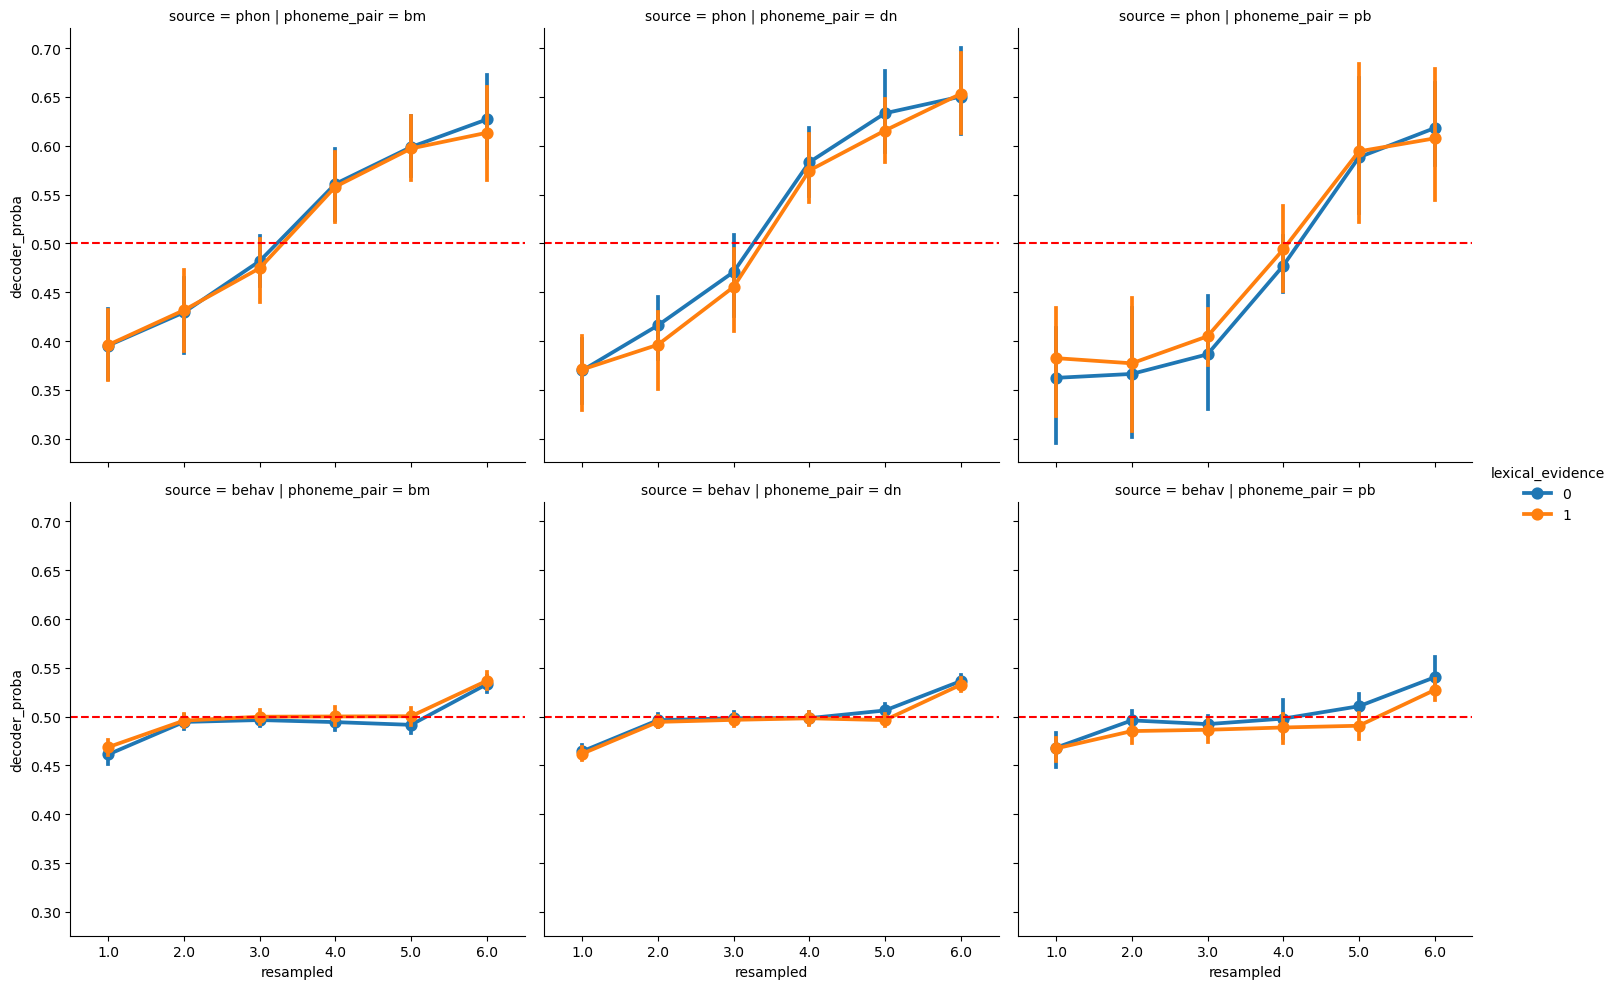

In [ ]:
# Resample at the level of site for estimating CIs
plot_phon_df["site"] = plot_phon_df.subject.astype(str) + "_" + plot_phon_df.electrode_idx.astype(str) + "_" + plot_phon_df.phoneme_pair.astype(str)

g = sns.catplot(data=plot_phon_df.reset_index(), x="resampled", y="decoder_proba", hue="lexical_evidence",
                col="phoneme_pair", col_order=phoneme_pair_order,
                row="source", row_order=["phon", "behav"],
                kind="point", units="site")

for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

In [164]:
# compute phonetic accuracy per source and resampled, within fold
phon_acc = plot_phon_df.groupby(["source", "site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "smin", "smax", "fold"]) \
    .progress_apply(lambda xs: accuracy_score(xs.decoder_target == 1, xs.decoder_proba > 0.5)) \
    .rename("accuracy").reset_index()

  0%|          | 0/12120 [00:00<?, ?it/s]

In [165]:
# Pivot wider and get difference in accuracy depending on phon source vs behav source
assert phon_acc.groupby(["site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "fold"]).size().max() <= 2

# NB we are doing dropna here -- so those phon sites which are predictive of phon but
# not predictive of behav aren't included in the comparison
phon_acc_change = phon_acc.pivot_table(
    index=["site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "fold"],
    columns="source",
    values="accuracy").dropna().assign(acc_diff=lambda df: df.phon - df.behav)

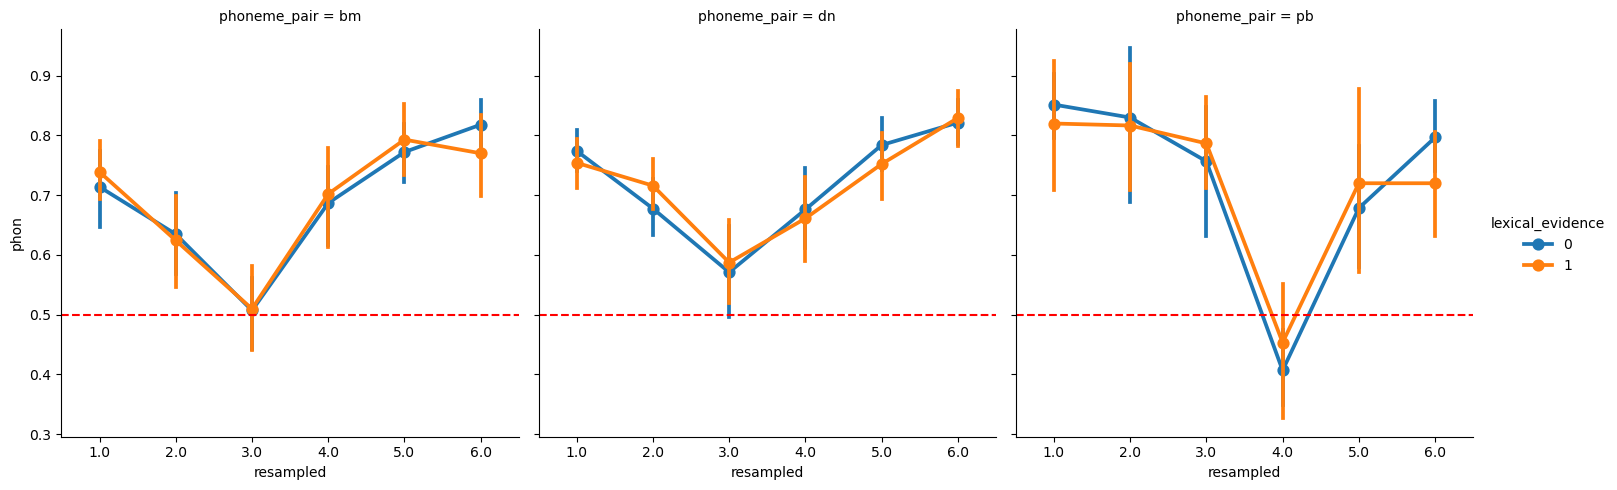

In [167]:
g = sns.catplot(data=phon_acc_change, x="resampled", y="phon", hue="lexical_evidence",
                col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

In [92]:
# from scipy.stats import ttest_1samp
# phon_acc_change.groupby(["phoneme_pair", "resampled", "lexical_evidence"]) \
#     .apply(lambda xs: pd.Series(ttest_1samp(xs["phon"], popmean=0.5), index=["t_stat", "p_value"])).sort_values("p_value")

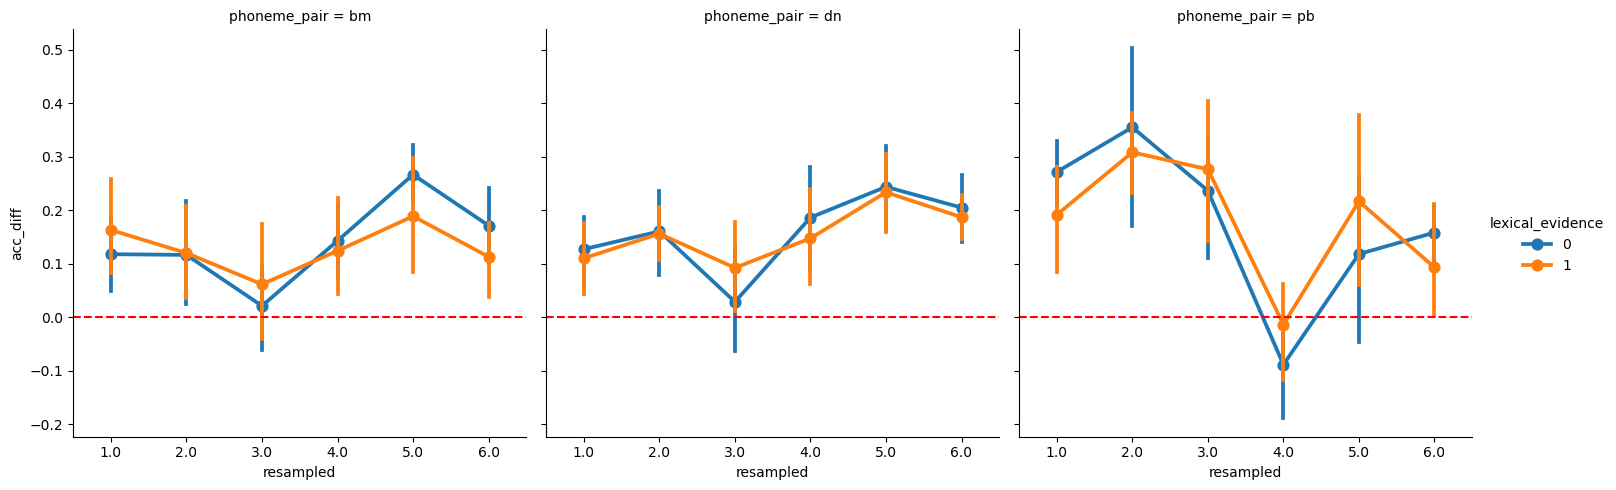

In [168]:
g = sns.catplot(data=phon_acc_change, x="resampled", y="acc_diff", hue="lexical_evidence",
                col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
for ax in g.axes.flat:
    ax.axhline(0, color="red", linestyle="--")

In [94]:
# from scipy.stats import ttest_1samp
# phon_acc_change.groupby(["phoneme_pair", "resampled", "lexical_evidence"]) \
#     .apply(lambda xs: pd.Series(ttest_1samp(xs["acc_diff"], popmean=0), index=["t_stat", "p_value"])).sort_values("p_value")

## Behav prediction

In [170]:
plot_phon_behav_keys = phon_peaks_df[["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]]
plot_phon_behav_df = pd.merge(
    plot_phon_behav_keys, behav_pred_df,
    on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
    how="left"
)
missing_phon_behav = plot_phon_behav_df.full_decoder_proba.isna()
if missing_phon_behav.any():
    L.warning(f"There are {missing_phon_behav.sum()} phonetic peaks without matching behavioral predictions.")
    L.warning("Examples:")
    L.warning(plot_phon_behav_df.loc[missing_phon_behav, ["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]].head())

plot_behav_behav_df = pd.merge(
    behav_peaks_df, behav_pred_df,
    on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax", "word_end"],
    how="left"
)
missing_behav_behav = plot_behav_behav_df.full_decoder_proba.isna()
if missing_behav_behav.any():
    L.warning(f"There are {missing_behav_behav.sum()} behavioral peaks without matching behavioral predictions.")
    L.warning("Examples:")
    L.warning(plot_behav_behav_df.loc[missing_behav_behav, ["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]].head())

2026-01-29 11:35:33.739 | WARNING  | __main__:<module>:9 - There are 2 phonetic peaks without matching behavioral predictions.
2026-01-29 11:35:33.741 | WARNING  | __main__:<module>:10 - Examples:
2026-01-29 11:35:33.742 | WARNING  | __main__:<module>:11 -      subject  electrode_idx phoneme_pair  smin  smax
9268   EC282            117           bm    55    70
9269   EC282            117           dn    55    70


In [171]:
plot_behav_df = pd.concat([
    plot_phon_behav_df.assign(source="phon"),
    plot_behav_behav_df.assign(source="behav")
])

plot_behav_df = plot_behav_df.merge(
    all_md,
    on=["subject", "epoch_idx", "phoneme_pair", "word_end"],
    how="left"
)

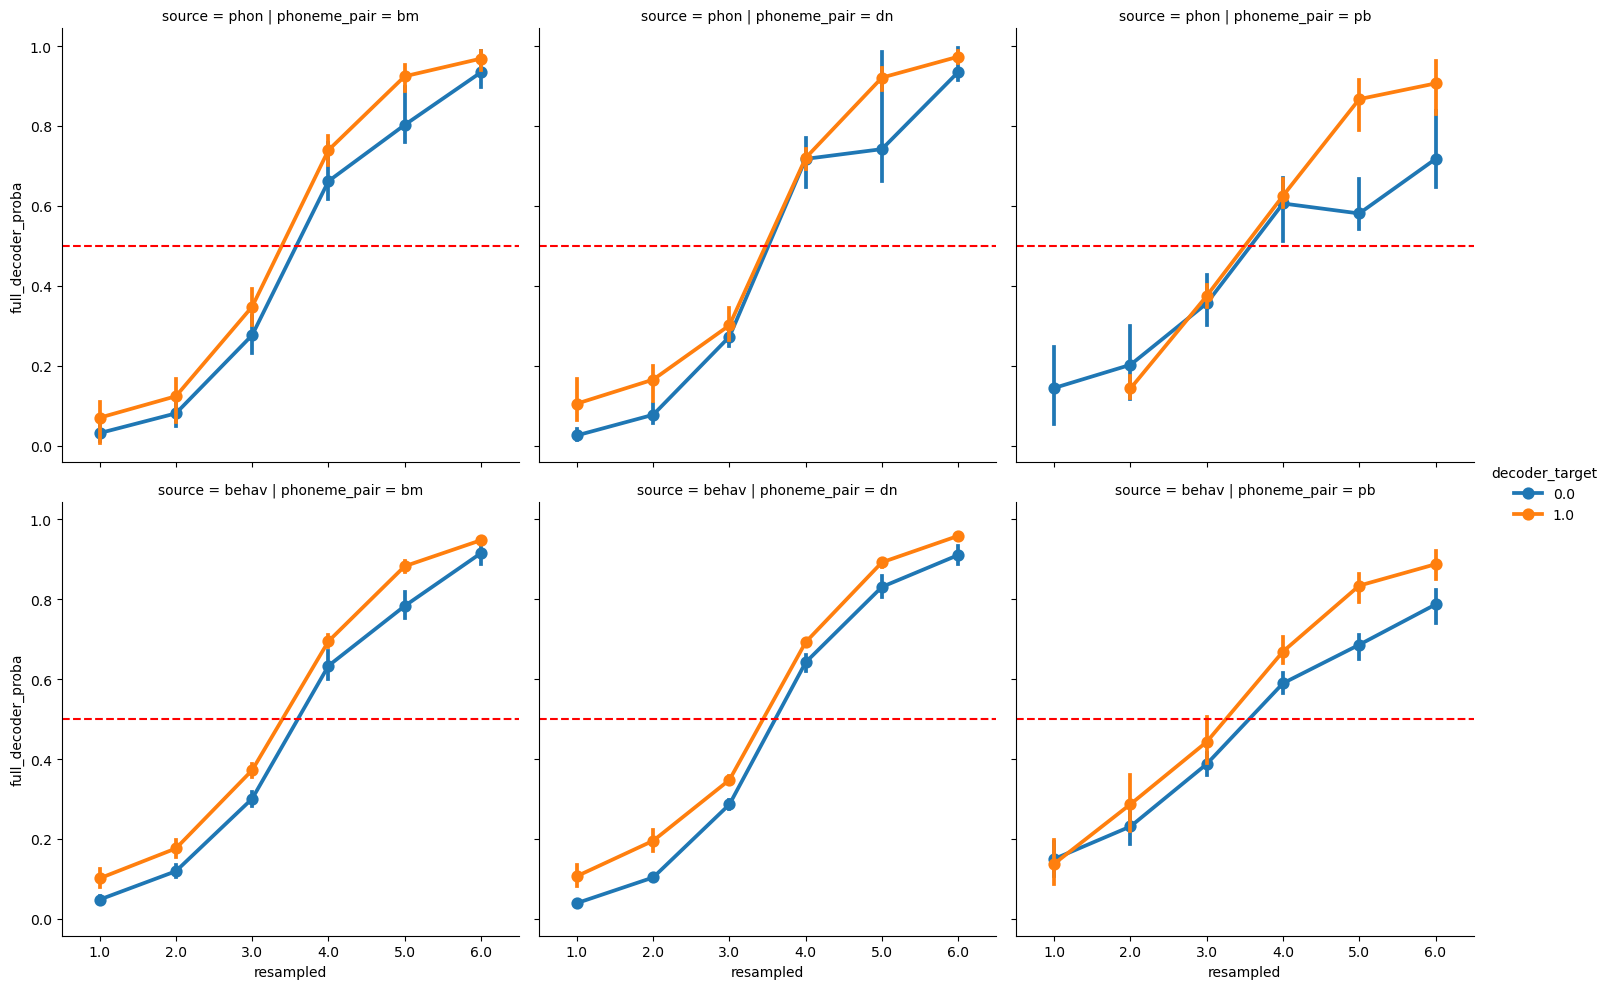

In [173]:
# Resample at the level of site for estimating CIs
plot_behav_df["site"] = plot_behav_df.subject.astype(str) + "_" + plot_behav_df.electrode_idx.astype(str) + "_" + plot_behav_df.phoneme_pair.astype(str)

g = sns.catplot(data=plot_behav_df, x="resampled", y="full_decoder_proba", hue="decoder_target",
                col="phoneme_pair", col_order=phoneme_pair_order,
                row="source", row_order=["phon", "behav"],
                kind="point", units="site")

for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

In [174]:
# TODO is fillna=1 right here?
behav_roc_auc = plot_behav_df.groupby(["source", "subject", "electrode_idx", "phoneme_pair", "word_end", "resampled", "smin", "smax", "fold"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.full_decoder_proba)) \
    .rename("roc_auc").reset_index()

behav_roc_auc_improvement = plot_behav_df.groupby(["source", "subject", "electrode_idx", "phoneme_pair", "word_end", "resampled", "smin", "smax", "fold"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.full_decoder_proba) - roc_auc_score(xs.decoder_target, xs.baseline_decoder_proba)) \
    .rename("roc_auc_improvement").reset_index()

  0%|          | 0/11832 [00:00<?, ?it/s]

/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is

  0%|          | 0/11832 [00:00<?, ?it/s]

/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is

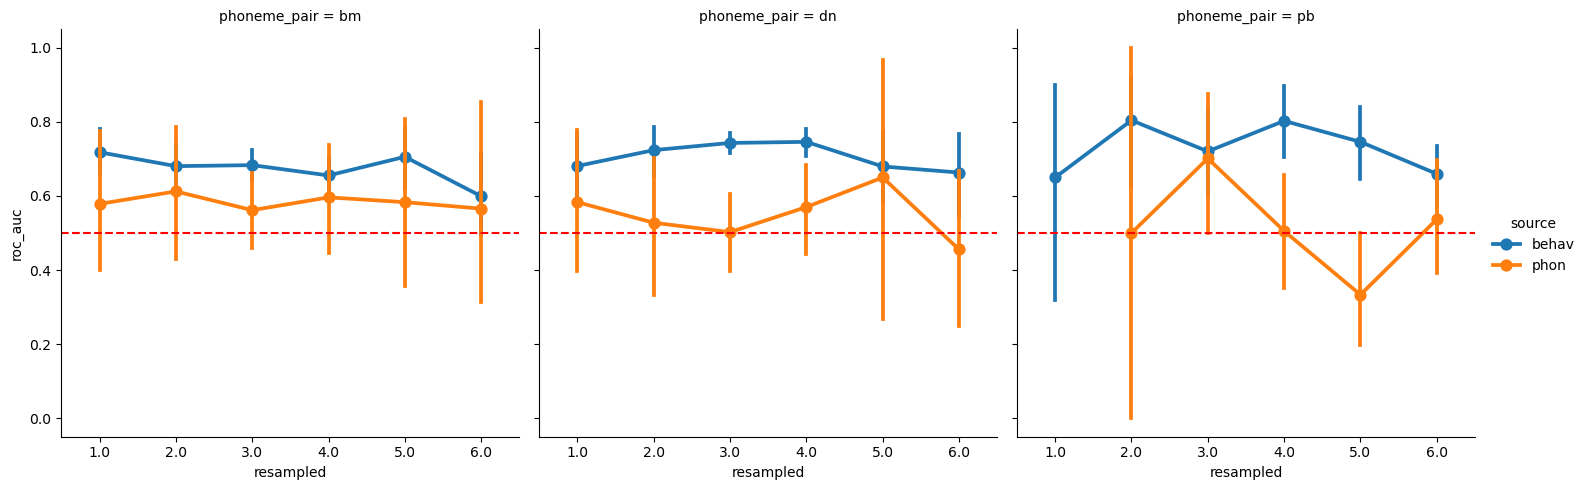

In [176]:
behav_roc_auc["site"] = behav_roc_auc.subject.astype(str) + "_" + behav_roc_auc.electrode_idx.astype(str) + "_" + behav_roc_auc.phoneme_pair.astype(str) + "_" + behav_roc_auc.word_end.astype(str)

g = sns.catplot(data=behav_roc_auc, x="resampled", y="roc_auc",
                hue="source", col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

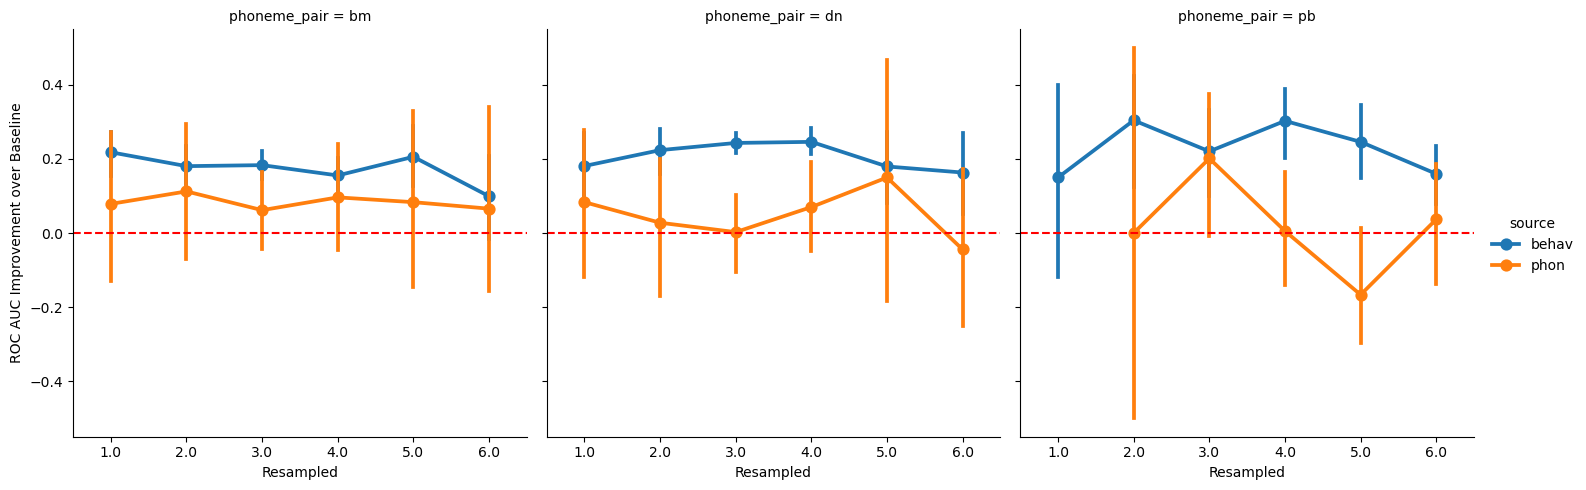

In [178]:
behav_roc_auc_improvement["site"] = behav_roc_auc_improvement.subject.astype(str) + "_" + behav_roc_auc_improvement.electrode_idx.astype(str) + "_" + behav_roc_auc_improvement.phoneme_pair.astype(str) + "_" + behav_roc_auc_improvement.word_end.astype(str)

g = sns.catplot(data=behav_roc_auc_improvement, x="resampled", y="roc_auc_improvement",
                hue="source", col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
g.set_axis_labels("Resampled", "ROC AUC Improvement over Baseline")

for ax in g.axes.flat:
    ax.axhline(0, color="red", linestyle="--")

## Zoomout: reproduce overall transfer result

### Phon prediction

In [95]:
# Compute overall phon ROC-AUC across resampled steps for a given site + electrode idx
# compare the latest behav window with the phon window
phon_roc_auc_overall = plot_phon_df.groupby(["source", "subject", "electrode_idx", "smin", "smax", "phoneme_pair"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.decoder_proba)) \
    .rename("roc_auc").reset_index() \
    .sort_values("smax", ascending=False) \
    .groupby(["source", "subject", "electrode_idx", "phoneme_pair"]).first().reset_index()

  0%|          | 0/494 [00:00<?, ?it/s]

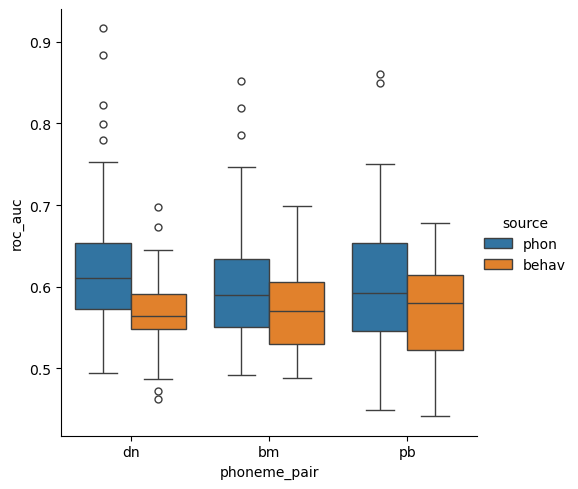

In [96]:
sns.catplot(data=phon_roc_auc_overall, x="phoneme_pair", y="roc_auc",
            hue="source", hue_order=["phon", "behav"], kind="box")

    source subject  electrode_idx phoneme_pair  smin  smax   roc_auc word_end
0    behav   EC243             85           dn   269   284  0.472608       NA
167   phon   EC243             85           dn    40    70  0.527249       NA
2
2
    source subject  electrode_idx phoneme_pair  smin  smax   roc_auc word_end
1    behav   EC243             86           dn   225   240  0.550540       NA
168   phon   EC243             86           dn    40    70  0.540404       NA
2
2
    source subject  electrode_idx phoneme_pair  smin  smax   roc_auc word_end
3    behav   EC243             87           dn   249   264  0.490355       NA
170   phon   EC243             87           dn    40    70  0.670484       NA
2
2
    source subject  electrode_idx phoneme_pair  smin  smax   roc_auc word_end
4    behav   EC243             96           dn   245   260  0.561921       NA
171   phon   EC243             96           dn    40    70  0.543517       NA
2
2
    source subject  electrode_idx phoneme_pair  

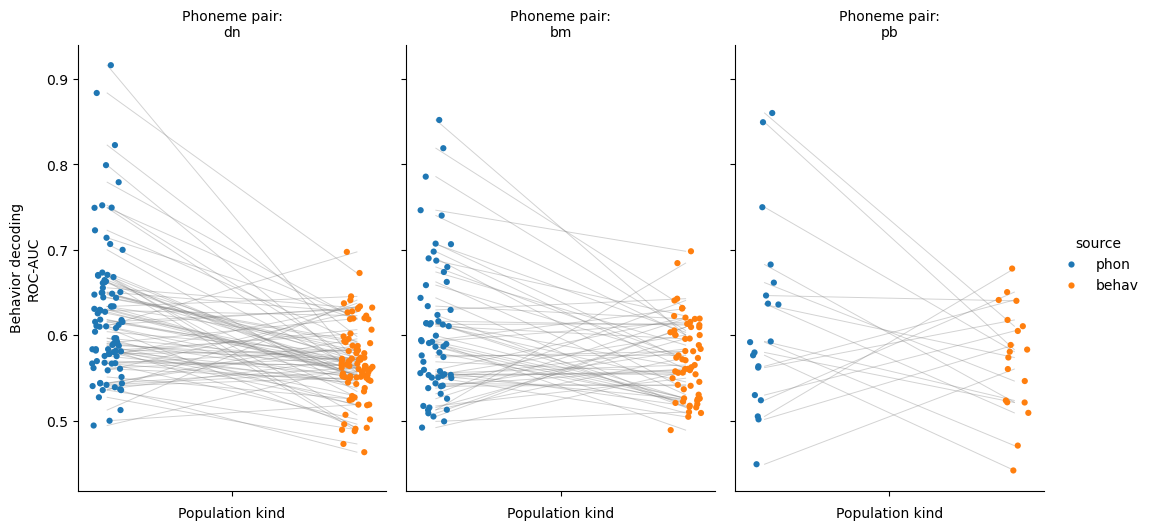

In [97]:
from src.viz import spaghetti_plot
spaghetti_plot(phon_roc_auc_overall.assign(word_end="NA"),
               y="roc_auc", by1="phon", by2="behav", by="source",
               col="phoneme_pair")

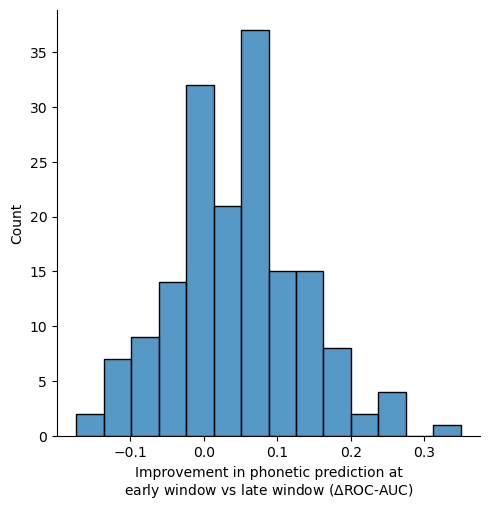

In [98]:
g = sns.displot(x="source_diff", data=phon_roc_auc_overall.pivot_table(
    index=["subject", "electrode_idx", "phoneme_pair"],
    columns="source",
    values="roc_auc"
).dropna().assign(source_diff=lambda df: df.phon - df.behav))
g.set_axis_labels("Improvement in phonetic prediction at\nearly window vs late window ($\Delta$ROC-AUC)")

### Behav prediction

In [127]:
# summarize behavior prediction roc-auc
# keep the latest window of results for each behavior site
behav_roc_auc_overall_behav = plot_behav_behav_df.groupby(["subject", "electrode_idx", "smin", "smax", "phoneme_pair", "word_end"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.full_decoder_proba)) \
    .rename("roc_auc").reset_index() \
    .sort_values("smax", ascending=False) \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end"]).first().reset_index()

  0%|          | 0/653 [00:00<?, ?it/s]

In [128]:
# summarize behavior prediction roc-auc at phon windows
behav_roc_auc_overall_phon = plot_phon_behav_df.groupby(["subject", "electrode_idx", "smin", "smax", "phoneme_pair", "word_end"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.full_decoder_proba)) \
    .rename("roc_auc").reset_index() \
    .sort_values("smax", ascending=False) \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end"]).first().reset_index()

  0%|          | 0/332 [00:00<?, ?it/s]

In [129]:
# only retain phon results for those sites that appeared in behav results
behav_roc_auc_overall_phon = pd.merge(
    behav_roc_auc_overall_phon,
    behav_roc_auc_overall_behav[["subject", "electrode_idx", "phoneme_pair", "word_end"]],
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    how="inner"
)

In [135]:
# Also compute ROC-AUC for the baseline behavior decoder
behav_roc_auc_overall_baseline = pd.merge(plot_behav_phon_keys, behav_ensemb_df,
         on=["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"],
         how="inner") \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.baseline_decoder_proba)) \
    .rename("roc_auc").reset_index()

  0%|          | 0/331 [00:00<?, ?it/s]

In [136]:
behav_roc_auc_overall = pd.concat([
    behav_roc_auc_overall_behav.assign(source="behav"),
    behav_roc_auc_overall_phon.assign(source="phon"),
    behav_roc_auc_overall_baseline.assign(source="baseline")
], ignore_index=True)

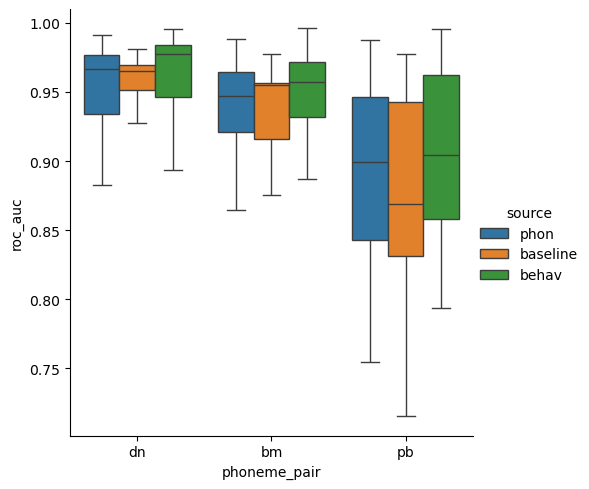

In [137]:
sns.catplot(data=behav_roc_auc_overall, x="phoneme_pair", y="roc_auc",
            hue="source", hue_order=["phon", "baseline", "behav"], kind="box",
            showfliers=False)

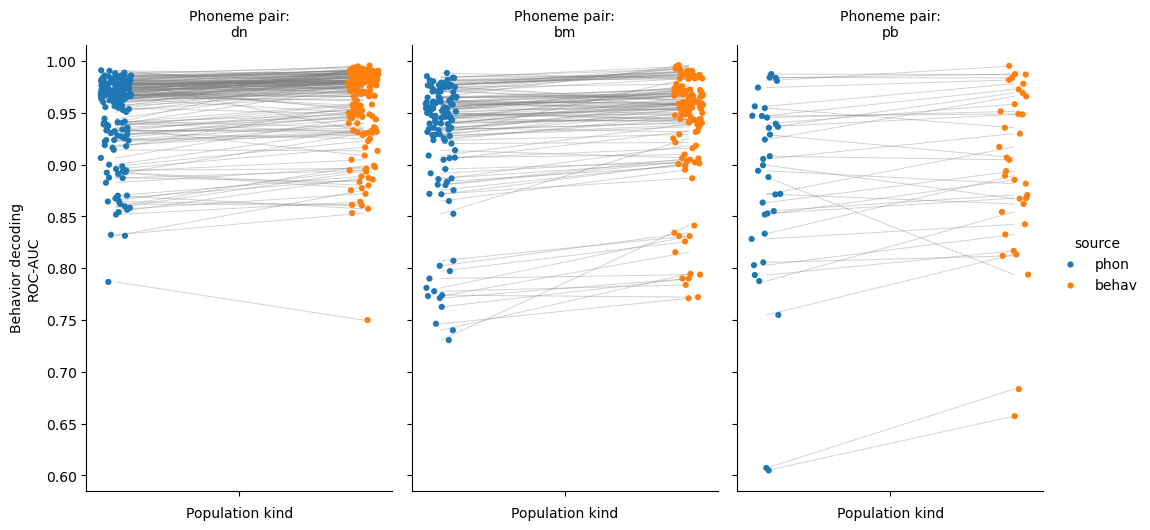

In [139]:
spaghetti_plot(behav_roc_auc_overall.query("source in ['phon', 'behav']"),
               y="roc_auc", by1="phon", by2="behav", by="source",
               col="phoneme_pair")

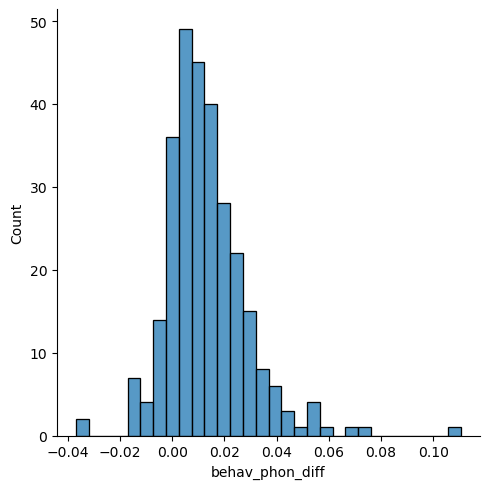

In [140]:
sns.displot(x="behav_phon_diff", data=behav_roc_auc_overall.pivot_table(
    index=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    columns="source",
    values="roc_auc"
).dropna().assign(behav_baseline_diff=lambda df: df.behav - df.baseline,
                  behav_phon_diff=lambda df: df.behav - df.phon).query("behav_baseline_diff > 0"))

## Zoomin

In [222]:
pd.merge(phon_sum_df,
         behav_sum_df[["subject", "electrode_idx", "phoneme_pair", "word_end", "diff"]].rename(columns={"diff": "behav_improvement"}),
         on=["subject", "electrode_idx", "phoneme_pair"], suffixes=("_phon", "_behav")) \
    .sort_values("roc_auc", ascending=False)[["subject", "electrode_idx", "phoneme_pair", "word_end", "roc_auc", "behav_improvement"]] \
    .drop_duplicates(["subject", "electrode_idx", "phoneme_pair", "word_end"]) \
    .head(30)

,subject,electrode_idx,phoneme_pair,word_end,roc_auc,behav_improvement
76,EC250,216,bm,bountiful,0.952,0.010480
77,EC250,216,bm,mountains,0.952,0.014480
188,EC253,21,bm,bountiful,0.950,0.010984
191,EC253,21,bm,mountains,0.950,0.005817
192,EC253,21,pb,beneficial,0.942,0.007932
195,EC253,21,pb,penecillin,0.942,0.000707
83,EC250,215,pb,penecillin,0.938,-0.067083
82,EC250,215,pb,beneficial,0.938,0.003864
84,EC250,215,dn,desolate,0.934,0.009903
85,EC250,215,dn,necessary,0.934,0.010868


In [210]:
def zoomin(subject, electrode_idx, phoneme_pair):
    def keep_top_smax(rows):
        keep_smax = rows.smax.max()
        return rows.query(f"smax == {keep_smax}")

    # phonetic predictions
    subplot_phon_phon_df = plot_phon_phon_df.reset_index().query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    subplot_behav_phon_df = plot_behav_phon_df.reset_index().query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    # keep only one behavioral window (the latest one); nb this may be different for the two word ends
    subplot_behav_phon_df = subplot_behav_phon_df.groupby("word_end").apply(keep_top_smax).reset_index(drop=True)

    # behav predictions
    subplot_behav_behav_df = plot_behav_behav_df.reset_index().query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    subplot_phon_behav_df = plot_phon_behav_df.reset_index().query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    # keep only one behavioral window (the latest one); nb this may be different for the two word ends
    subplot_behav_behav_df = subplot_behav_behav_df.groupby("word_end").apply(keep_top_smax).reset_index(drop=True)

    assert subplot_phon_phon_df.smin.nunique() == 1
    assert subplot_behav_phon_df.groupby("word_end").smin.nunique().max() == 1
    assert subplot_behav_behav_df.groupby("word_end").smin.nunique().max() == 1
    assert subplot_phon_behav_df.smin.nunique() == 1

    subplot_phon_df = pd.concat([
        subplot_phon_phon_df.assign(source="phon"),
        subplot_behav_phon_df.assign(source="behav")
    ])
    subplot_behav_df = pd.concat([
        subplot_phon_behav_df.assign(source="phon"),
        subplot_behav_behav_df.assign(source="behav")
    ])

    print("Phonetic window:", subplot_phon_phon_df.smin.min(), "-", subplot_phon_phon_df.smax.max())
    print("Behavioral window:", subplot_behav_behav_df.smin.min(), "-", subplot_behav_behav_df.smax.max())

    sub_phon_acc_change = phon_acc_change.query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    sub_behav_roc_auc = behav_roc_auc.query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    sub_behav_roc_auc_improvement = behav_roc_auc_improvement.query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")

    # Also compute overall phonetic and behavioral ROC-AUC
    phon_phon_roc_auc = roc_auc_score(subplot_phon_phon_df.decoder_target, subplot_phon_phon_df.decoder_proba)
    behav_phon_roc_auc = roc_auc_score(subplot_behav_phon_df.decoder_target, subplot_behav_phon_df.decoder_proba)
    behav_behav_roc_auc = roc_auc_score(subplot_behav_behav_df.decoder_target, subplot_behav_behav_df.full_decoder_proba)
    phon_behav_roc_auc = roc_auc_score(subplot_phon_behav_df.decoder_target, subplot_phon_behav_df.full_decoder_proba)
    roc_auc_heatmap_df = pd.DataFrame({
        "source": ["phon", "phon", "behav", "behav"],
        "target": ["phon", "behav", "phon", "behav"],
        "roc_auc": [phon_phon_roc_auc, phon_behav_roc_auc, behav_phon_roc_auc, behav_behav_roc_auc]
    }).pivot(index="source", columns="target", values="roc_auc")

    f, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(roc_auc_heatmap_df, annot=True, vmin=0.5, vmax=1.0, cmap="Blues", ax=ax)

    g_phon = sns.catplot(
        data=subplot_phon_df,
        x="resampled", y="decoder_proba", hue="lexical_evidence",
        col="source", col_order=["phon", "behav"],
        kind="point", height=4)
    for ax in g_phon.axes.flat:
        ax.axhline(0.5, color="red", linestyle="--")

    g_phon_acc_change = sns.catplot(
        data=sub_phon_acc_change,
        x="resampled", y="acc_diff", hue="lexical_evidence",
        kind="point", height=3)
    g_phon_acc_change.figure.suptitle("Improvement in phonetic decoding\nat phon - behav window")
    for ax in g_phon_acc_change.axes.flat:
        ax.axhline(0, color="red", linestyle="--")

    g_behav = sns.catplot(
        data=subplot_behav_df,
        x="resampled", y="full_decoder_proba", hue="decoder_target",
        col="source", col_order=["phon", "behav"],
        kind="point", height=4)
    for ax in g_behav.axes.flat:
        ax.axhline(0.5, color="red", linestyle="--")

    g_behav_roc_auc = sns.catplot(
        data=sub_behav_roc_auc,
        x="resampled", y="roc_auc",
        hue="source", col="word_end",
        kind="point", height=3)
    g_behav_roc_auc.set_axis_labels("Resampled", "ROC AUC")
    for ax in g_behav_roc_auc.axes.flat:
        ax.axhline(0.5, color="red", linestyle="--")

    g_behav_roc_auc_improvement = sns.catplot(
        data=sub_behav_roc_auc_improvement,
        x="resampled", y="roc_auc",
        hue="source", col="word_end",
        kind="point", height=3)
    g_behav_roc_auc_improvement.set_axis_labels("Resampled", "ROC AUC Improvement\nover Baseline")
    for ax in g_behav_roc_auc_improvement.axes.flat:
        ax.axhline(0, color="red", linestyle="--")

    return g_phon, g_phon_acc_change, g_behav, g_behav_roc_auc, g_behav_roc_auc_improvement